<a href="https://colab.research.google.com/github/Abidau/PCVK_Ganjil_26-27/blob/main/Week5_No20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Naufal Abid Aurizky'
NIM  = '244107020212'

N = int(NIM[-3:])
PARAM = {
    'b'    : (N % 61) + 20,
    'a'    : round(1.0 + (N % 9) / 10, 1),
    'c'    : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit'  : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Naufal Abid Aurizky
NIM    : 244107020212 | N = 212
b      : 49
a      : 1.5
c      : 42
gamma  : 0.9
bit    : 4
WAKTU  : 2026-09-22 13:49:21 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 76fc0ae495e22695


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

BASE = '/content/drive/MyDrive/PCVK/Images/' + NIM

def cv2_imshow_rgb(ax, img, title):
    """Menampilkan citra BGR (OpenCV) sebagai RGB di axis matplotlib"""
    if len(img.shape) == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def tampil_2(img1, img2, judul1, judul2, figsize=(10,5)):
    fig, axs = plt.subplots(1, 2, figsize=figsize)
    cv2_imshow_rgb(axs[0], img1, judul1)
    cv2_imshow_rgb(axs[1], img2, judul2)
    plt.tight_layout()
    plt.show()

print(BASE)

/content/drive/MyDrive/PCVK/Images/244107020212


<BarContainer object of 256 artists>

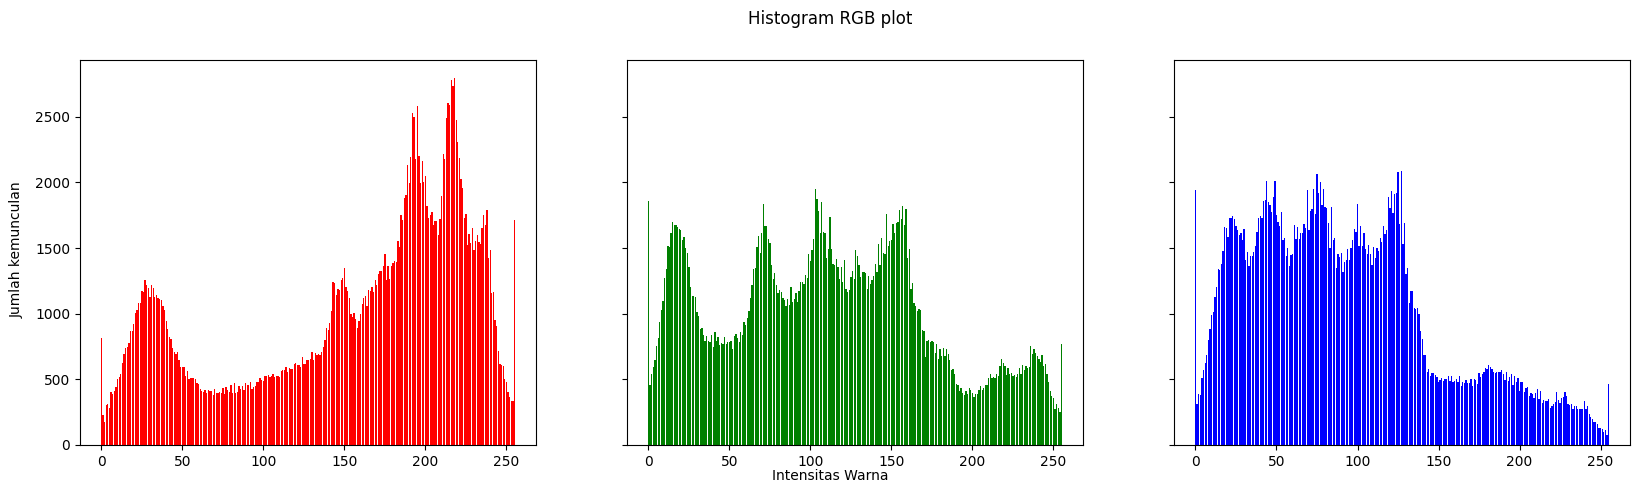

In [5]:
img = cv.imread(BASE + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0, width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

## Pertanyaan Praktikum E1